## Thelia的手撕线性回归尝试！

### 随机生成一个数据集吧~

In [747]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import time

n_samples = 50
seed = int(time.time())  # 每分钟更新一次随机种子，确保每次运行生成不同的样本
# 原函数参数 y = a * x + b
random.seed(seed)
a = random.uniform(-4, 4)
b = random.uniform(-10, 10)

# 方差与样本数（方差越大，点越分散）
noise_std = random.uniform(5, 10) * abs(a)
rng = np.random.default_rng(seed)
x = np.arange(1, n_samples + 1)
noise = rng.normal(0, noise_std, size=n_samples)
y = a * x + b + noise

df = pd.DataFrame({
    'x': x,
    'y': np.round(y, 1),
})

csv_path = Path('linear_regression_sample.csv')
df.to_csv(csv_path, index=False)
print(f'已生成 {n_samples} 条样本，保存到: {csv_path.resolve()}')
df.head()

已生成 50 条样本，保存到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/linear_regression_sample.csv


,x,y
0,1,4.3
1,2,-4.3
2,3,-23.3
3,4,-28.1
4,5,-9.5


### 导入包

In [748]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 导入数据

In [749]:
dataset = pd.read_csv('linear_regression_sample.csv')
print(dataset)
X = dataset.iloc[:, :-1].values #输入矩阵
y = dataset.iloc[:, -1].values #输出矩阵

     x      y
0    1    4.3
1    2   -4.3
2    3  -23.3
3    4  -28.1
4    5   -9.5
5    6  -39.3
6    7  -41.9
7    8  -50.3
8    9  -50.2
9   10  -22.5
10  11  -49.1
11  12  -17.3
12  13  -52.9
13  14  -54.7
14  15  -54.5
15  16  -65.8
16  17  -66.7
17  18  -58.2
18  19  -79.0
19  20  -87.5
20  21  -65.2
21  22  -67.4
22  23  -72.5
23  24  -70.3
24  25  -69.2
25  26  -79.4
26  27  -73.7
27  28  -75.3
28  29 -104.3
29  30  -90.1
30  31  -65.3
31  32  -56.5
32  33  -94.3
33  34  -95.5
34  35 -132.8
35  36 -103.4
36  37 -125.1
37  38 -115.2
38  39 -118.2
39  40 -131.0
40  41 -111.7
41  42 -148.3
42  43 -140.2
43  44 -132.6
44  45 -160.3
45  46 -153.7
46  47 -145.7
47  48 -137.6
48  49 -111.9
49  50 -125.4


#### 试着画个散点图？

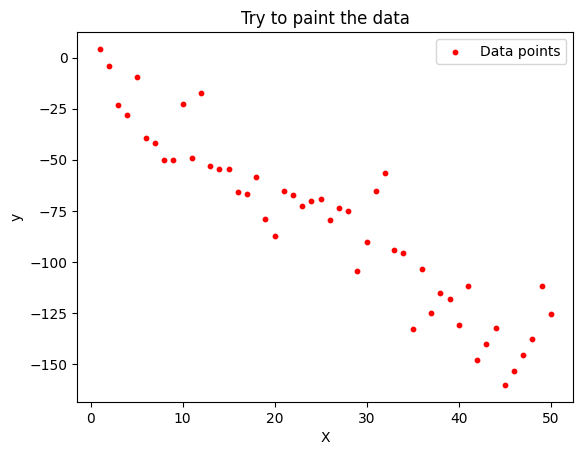

In [750]:
plt.scatter(X, y, color='red', s=10, label='Data points')
plt.title('Try to paint the data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### 划分一下训练数据和测试数据~

In [751]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

### 线性回归，启动！

In [752]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iters=30000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape #数据量&特征数
        # 初始化权重和偏置
        self.w = np.zeros(n_features)
        self.b = 0

        # 梯度下降
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.w) + self.b
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.w) + self.b
        return linear_model
        

### 训练一下

In [753]:
LM = LinearRegression()
LM.fit(X_train, y_train)

### 看看结果

Learned parameters: w=-2.6273, b=-14.6787
True parameters: w=-2.6738, b=-7.7680
Test MSE: 388.4865
Given MSE:313.5393


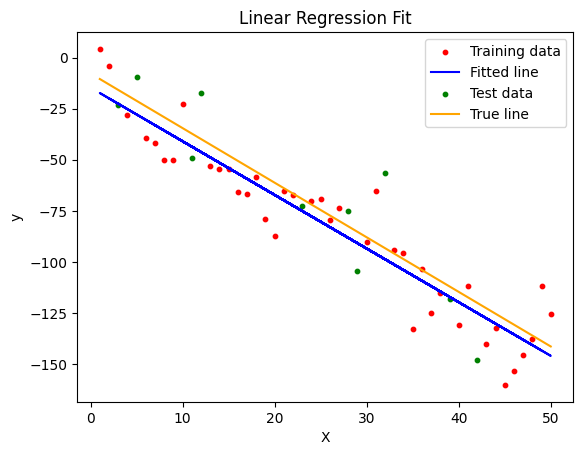

In [ ]:
plt.scatter(X_train, y_train, color='red', s=10, label='Training data')
plt.plot(X_train, LM.predict(X_train), color='blue', label='Fitted line')
plt.scatter(X_test, y_test, color='green', s=10, label='Test data')
plt.plot(X, a * X + b, color='orange', label='True line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Training data','Fitted line','Test data','True line'])
print(f'Learned parameters: w={LM.w[0]:.4f}, b={LM.b:.4f}')
print(f'True parameters: w={a:.4f}, b={b:.4f}')
print(f'Test MSE: {np.mean((LM.predict(X_test) - y_test) ** 2):.4f}')
print(f'Preset Variance: {noise_std**2:.4f}')